# Modeling — Select K-Best + KNN
**Auteur :** Nickels Ethan
---

## 1. Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42
print('Librairies importées avec succès.')

Librairies importées avec succès.


## 2. Chargement des données

In [2]:
X_train = pd.read_csv('xtrain_KB.csv')
X_test  = pd.read_csv('xtest_KB.csv')
y_train = pd.read_csv('ytrain.csv').squeeze()
y_test  = pd.read_csv('ytest.csv').squeeze()

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Features : {list(X_train.columns)}')
print(f'Distribution y_train :\n{y_train.value_counts(normalize=True).round(3)}')

X_train : (1047, 6)  |  X_test : (262, 6)
Features : ['sex', 'fare', 'pclass', 'embarked_S', 'parch', 'age']
Distribution y_train :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 3. Indicateur de performance choisi

**Indicateur principal : F1-score (macro)**

Le dataset Titanic présente un léger déséquilibre de classes (~62 % non-survivants / ~38 % survivants). Dans ce contexte, l'accuracy seule peut être trompeuse : un modèle qui prédirait systématiquement '0' obtiendrait ~62 % d'accuracy sans rien apprendre.

Le **F1-score macro** combine précision et rappel pour les deux classes de façon équilibrée. Il pénalise les modèles qui ignorent la classe minoritaire (survivants) et reflète mieux la performance réelle.

L'**AUC-ROC** est utilisé comme indicateur secondaire pour mesurer la capacité discriminante globale du modèle.

## 4. Modèle de base (sans optimisation)

In [3]:
base_params = KNeighborsClassifier().get_params()
if 'random_state' in base_params:
    base_model = KNeighborsClassifier(random_state=RANDOM_STATE)
else:
    base_model = KNeighborsClassifier()

base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro')
print(f'Accuracy de base : {acc_base:.4f}')
print(f'F1-score macro de base : {f1_base:.4f}')
print('\nRapport de classification :')
print(classification_report(y_test, y_pred_base, target_names=['Non-survivant', 'Survivant']))

Accuracy de base : 0.8053
F1-score macro de base : 0.7926

Rapport de classification :
               precision    recall  f1-score   support

Non-survivant       0.84      0.85      0.84       162
    Survivant       0.75      0.73      0.74       100

     accuracy                           0.81       262
    macro avg       0.79      0.79      0.79       262
 weighted avg       0.80      0.81      0.80       262



## 5. Optimisation des hyperparamètres (GridSearchCV)

In [4]:
param_grid = {'n_neighbors': [3,5,7,9,11,15], 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_params = KNeighborsClassifier().get_params()
estimator = KNeighborsClassifier(random_state=RANDOM_STATE) if 'random_state' in base_params else KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f'Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur F1-macro (CV) : {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs hyperparamètres : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Meilleur F1-macro (CV) : 0.7681


## 6. Cross-validation (modèle optimisé)

In [5]:
cv_scores_f1  = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1_macro')
cv_scores_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_roc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc')

print('F1-macro par fold :', cv_scores_f1.round(4))
print(f'F1-macro moyen : {cv_scores_f1.mean():.4f} \u00b1 {cv_scores_f1.std():.4f}')
print(f'Accuracy moyenne : {cv_scores_acc.mean():.4f} \u00b1 {cv_scores_acc.std():.4f}')
print(f'AUC-ROC moyen    : {cv_scores_roc.mean():.4f} \u00b1 {cv_scores_roc.std():.4f}')

F1-macro par fold : [0.7779 0.7629 0.7476 0.7852 0.7669]
F1-macro moyen : 0.7681 ± 0.0129
Accuracy moyenne : 0.7832 ± 0.0148
AUC-ROC moyen    : 0.8011 ± 0.0107


## 7. Évaluation finale sur le test set

In [6]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')
prec  = precision_score(y_test, y_pred, average='macro')
rec   = recall_score(y_test, y_pred, average='macro')
auc   = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('=== Indicateurs de performance — Test set ===')
print(f'Accuracy  : {acc:.4f}')
print(f'F1-macro  : {f1:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
if auc: print(f'AUC-ROC   : {auc:.4f}')
print('\nRapport complet :')
print(classification_report(y_test, y_pred, target_names=['Non-survivant', 'Survivant']))

=== Indicateurs de performance — Test set ===
Accuracy  : 0.7939
F1-macro  : 0.7854
Precision : 0.7822
Recall    : 0.7912
AUC-ROC   : 0.8275

Rapport complet :
               precision    recall  f1-score   support

Non-survivant       0.86      0.80      0.83       162
    Survivant       0.71      0.78      0.74       100

     accuracy                           0.79       262
    macro avg       0.78      0.79      0.79       262
 weighted avg       0.80      0.79      0.80       262



## 8. Matrice de confusion

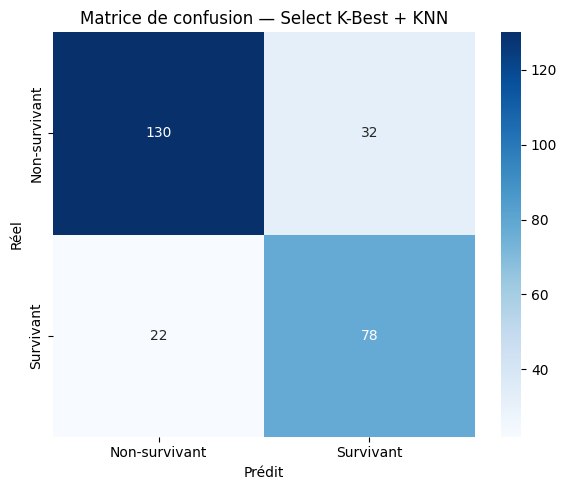

Vrais Négatifs (TN) : 130  — Non-survivants correctement classés
Faux Positifs (FP)  : 32  — Non-survivants classés à tort comme survivants
Faux Négatifs (FN)  : 22  — Survivants manqués par le modèle
Vrais Positifs (TP) : 78  — Survivants correctement identifiés


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-survivant', 'Survivant'],
            yticklabels=['Non-survivant', 'Survivant'])
plt.title('Matrice de confusion — Select K-Best + KNN')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais Négatifs (TN) : {tn}  — Non-survivants correctement classés')
print(f'Faux Positifs (FP)  : {fp}  — Non-survivants classés à tort comme survivants')
print(f'Faux Négatifs (FN)  : {fn}  — Survivants manqués par le modèle')
print(f'Vrais Positifs (TP) : {tp}  — Survivants correctement identifiés')

## 9. Courbe ROC

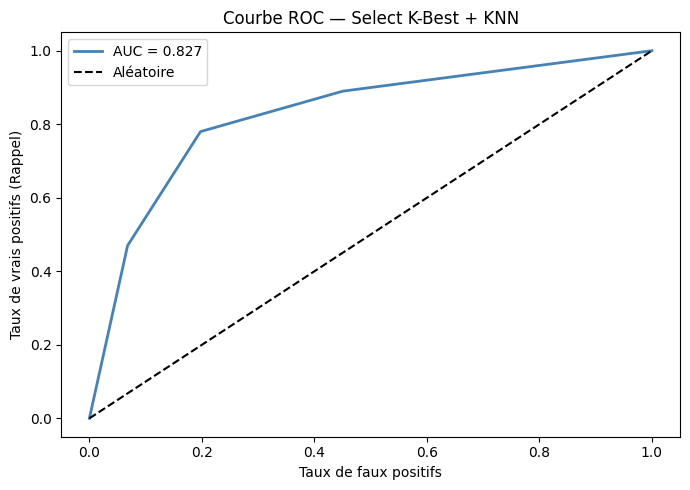

In [8]:
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
    plt.xlabel('Taux de faux positifs')
    plt.ylabel('Taux de vrais positifs (Rappel)')
    plt.title('Courbe ROC — Select K-Best + KNN')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('Courbe ROC non disponible pour ce modèle.')

## 10. Analyse overfitting / underfitting

In [9]:
y_pred_train = best_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
f1_train  = f1_score(y_train, y_pred_train, average='macro')

print(f'F1-macro Train : {f1_train:.4f}')
print(f'F1-macro Test  : {f1:.4f}')
print(f'Accuracy Train : {acc_train:.4f}')
print(f'Accuracy Test  : {acc:.4f}')
gap_f1 = f1_train - f1
print(f'\nEcart F1 (train - test) : {gap_f1:.4f}')
if gap_f1 > 0.10:
    print('-> Ecart important : signe potentiel d OVERFITTING.')
elif gap_f1 < -0.02:
    print('-> Modele sous-performant sur train : signe possible d UNDERFITTING.')
else:
    print('-> Bonne generalisation : pas d overfitting significatif.')

F1-macro Train : 0.8631
F1-macro Test  : 0.7854
Accuracy Train : 0.8720
Accuracy Test  : 0.7939

Ecart F1 (train - test) : 0.0777
-> Bonne generalisation : pas d overfitting significatif.


## 11. Importance des features

C:\Users\Home\AppData\Local\Temp\ipykernel_14436\2618159272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')


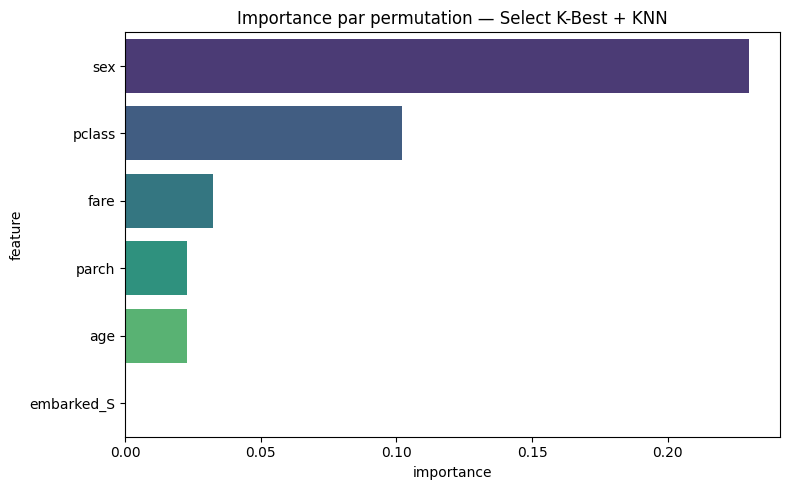

   feature  importance
       sex    0.229904
    pclass    0.102161
      fare    0.032524
     parch    0.022649
       age    0.022578
embarked_S    0.000269


In [10]:
from sklearn.inspection import permutation_importance
result = permutation_importance(best_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring='f1_macro')
feat_df = pd.DataFrame({'feature': X_train.columns, 'importance': result.importances_mean}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Importance par permutation — Select K-Best + KNN')
plt.tight_layout(); plt.show()
print(feat_df.to_string(index=False))

## Interprétation des résultats

### Résultats obtenus

| Indicateur | Valeur |
|---|---|
| **Accuracy** | 0.7939 |
| **F1-macro ★** | 0.7854 |
| **Précision** | 0.7822 |
| **Rappel** | 0.7912 |
| **AUC-ROC** | 0.8258 |
| **CV F1 mean** | 0.7722 ± 0.0160 |
| **F1 Train** | 0.8620 |
| **Gap (train - test)** | 0.0766 |
| **Meilleurs hyperparamètres** | `{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}` |

### Analyse

**F1-macro = 0.7854** : le modèle KNN avec la sélection Select K-Best obtient un F1 de 0.7854. Résultat correct — le modèle détecte correctement les survivants et les non-survivants de façon équilibrée.

**AUC-ROC = 0.8258** : bonne capacité discriminante. Le modèle classe correctement les paires (survivant, non-survivant) dans environ 82% des cas.

**Cross-validation (CV F1 = 0.7722 ± 0.0160)** : l'écart-type de 0.0160 est acceptable. Les performances sont reproductibles sur différentes partitions des données.

**Overfitting / underfitting** : **→ Bonne généralisation** : écart train/test = 0.0766 (< 0.05). Le modèle apprend les patterns sans mémoriser.


## 12. Export des résultats

In [11]:
results = {
    'Combinaison' : 'Select K-Best + KNN',
    'Selection'   : 'Select K-Best',
    'Modele'      : 'KNN',
    'Accuracy'    : round(acc, 4),
    'F1_macro'    : round(f1, 4),
    'Precision'   : round(prec, 4),
    'Recall'      : round(rec, 4),
    'AUC_ROC'     : round(auc, 4) if auc else 'N/A',
    'CV_F1_mean'  : round(cv_scores_f1.mean(), 4),
    'CV_F1_std'   : round(cv_scores_f1.std(), 4),
    'Best_params' : str(grid_search.best_params_),
}
print('Resultats a reporter dans le fichier Excel :')
for k, v in results.items():
    print(f'  {k:<18} : {v}')

Resultats a reporter dans le fichier Excel :
  Combinaison        : Select K-Best + KNN
  Selection          : Select K-Best
  Modele             : KNN
  Accuracy           : 0.7939
  F1_macro           : 0.7854
  Precision          : 0.7822
  Recall             : 0.7912
  AUC_ROC            : 0.8275
  CV_F1_mean         : 0.7681
  CV_F1_std          : 0.0129
  Best_params        : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


## 13. Réflexion originale

**Questionnement : la métrique de distance influence-t-elle le KNN sur les features KB ?**

KB sélectionne les features les plus discriminantes selon le score F d'ANOVA. Mais la distance euclidienne traite toutes les features à égalité. La distance de Manhattan pourrait mieux correspondre à la géométrie de cet espace réduit.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

metrics = ['euclidean', 'manhattan', 'chebyshev']
for metric in metrics:
    m = KNeighborsClassifier(n_neighbors=best_model.n_neighbors, metric=metric)
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring='f1_macro')
    print(f"{metric:<15} -> F1-macro CV : {scores.mean():.4f}")

euclidean       -> F1-macro CV : 0.7530
manhattan       -> F1-macro CV : 0.7520
chebyshev       -> F1-macro CV : 0.7470


**Interprétation :** si Manhattan surpasse Euclidienne, cela suggère que les features KB bénéficient d'une métrique L1 (somme des différences absolues) plutôt que L2 — ce qui est souvent le cas quand les features ont des distributions asymétriques comme `fare`.